# Exploratory Data Analysis and Data Visualization

This notebook explores behavior patterns in the February dataset, including distribution, top products, active users, and time-based insights. The final step exports an EDA-ready dataset for future analysis.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted", font_scale=1.3)
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
df = pd.read_csv("2020-Feb-Cleaned-300.csv")
df.head()

,product_id,category_id,price,user_id,price_standardized,hour,day_of_week,user_session,price_binned
0,100012116,2232732092356100446,40.41,604219459,-0.690543,2,5,58982ee1-36b0-4360-930b-d7fae51bb777,0-50
1,1005007,2232732093077520756,96.85,513695390,-0.533132,1,5,648f922d-ab40-4f29-8ee6-c67472ff0f27,51-100
2,1801940,2232732099754852875,218.77,526564962,-0.193097,2,5,f06a4c4e-67b3-4d0e-a0da-fe2c92105107,201-500
3,1004249,2232732093077520756,702.41,517047727,1.155776,3,5,c68c593c-3cfd-4a76-8bdf-e1e753afc1a6,500+
4,16001056,2053013556856619499,11.48,557759563,-0.771229,2,5,c29874f4-cf57-45db-8d1d-223be3376b3b,0-50


### Event Distribution
This Section examines how interactions are distributed across price bins, categories, and sessions. This helps reveal common behavior patterns and high-volume segments.

In [3]:
price_bin_counts = df['price_binned'].value_counts().sort_index()
category_counts = df['category_id'].value_counts().sort_index()
session_counts = df['user_session'].value_counts().sort_index()

print("Price Bin Distribution:\n", price_bin_counts)
print("\nTop 20 categories by interaction count:\n", category_counts.head(20))
print("\nTop 15 sessions by interaction count:\n", session_counts.head(15))

Price Bin Distribution:
 price_binned
0-50       578569
101-200    616246
201-500    701658
500+       206930
51-100     398718
Name: count, dtype: int64

Top 20 categories by interaction count:
 category_id
2053013551857008829       62
2053013551865397438       51
2053013551882174655      465
2053013551890563264        4
2053013551898951873      786
2053013551907340482     3539
2053013551924117699      166
2053013551932506308    13630
2053013551940894917       28
2053013551957672134     9314
2053013551966060743     1776
2053013552058335434       74
2053013552075112651      454
2053013552125444301       63
2053013552167387343     3470
2053013552192553169        2
2053013552226107603       64
2053013552259662037     5641
2053013552293216471     7052
2053013552326770905       46
Name: count, dtype: int64

Top 15 sessions by interaction count:
 user_session
0000131b-d5e8-46bb-b38b-92eb57de086d    1
00001ad4-a3f6-4446-ae37-36b3ed22f44a    1
00002278-8945-4505-aad8-3f3961c41f98    1
0000246

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

sns.barplot(x=price_bin_counts.index, y=price_bin_counts.values, ax=axes[0])
axes[0].set_title("Interaction Distribution by Price Bin")
axes[0].set_xlabel("Price Bin")
axes[0].set_ylabel("Interaction Count")

sns.barplot(x=category_counts.values, y=category_counts.index.astype(str), ax=axes[1])
axes[1].set_title("Top 20 Categories by Interaction Count")
axes[1].set_xlabel("Interaction Count")
axes[1].set_ylabel("Category ID")

sns.barplot(x=session_counts.values, y=session_counts.index.astype(str), ax=axes[2])
axes[2].set_title("Top 20 Sessions by Interaction Count")
axes[2].set_xlabel("Interaction Count")
axes[2].set_ylabel("Session ID")

plt.tight_layout()
plt.show()

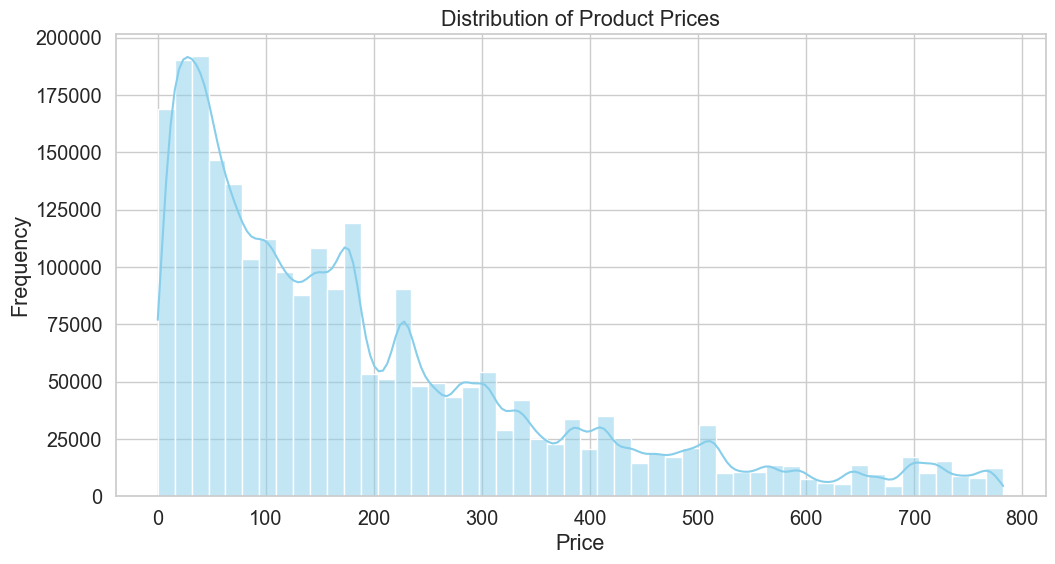

In [4]:
plt.figure(figsize=(12, 6))
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

C:\Users\phema\AppData\Local\Temp\ipykernel_7036\2211579196.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_binned', y='price', data=df, palette='Set2')


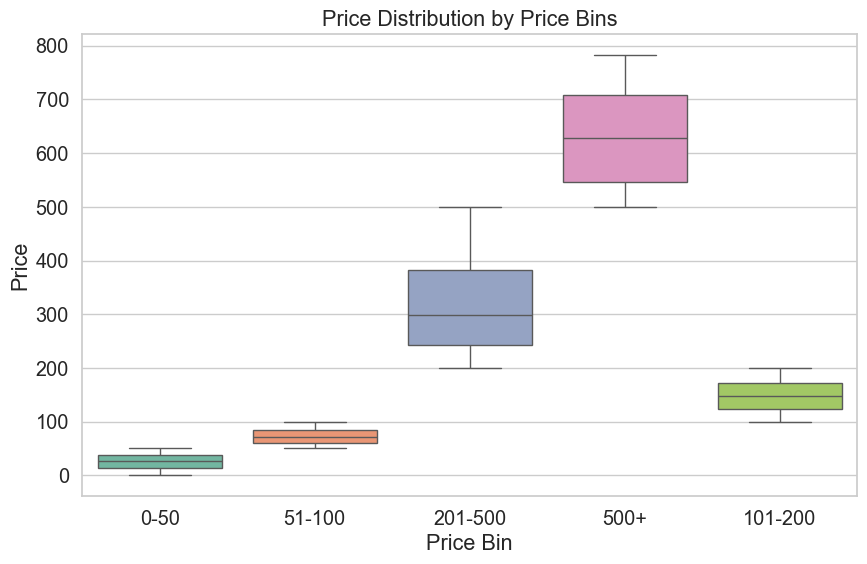

In [5]:
# Box plot for price by price bins
plt.figure(figsize=(10, 6))
sns.boxplot(x='price_binned', y='price', data=df, palette='Set2')
plt.title('Price Distribution by Price Bins')
plt.xlabel('Price Bin')
plt.ylabel('Price')
plt.show()

### Top Products
This section identify the most frequently interacted products. These top products are the strongest signals for product demand and behavior trends.

In [6]:
top_products = df['product_id'].value_counts().nlargest(20)
print("\nTop 20 products by interaction count:\n", top_products)


Top 20 products by interaction count:
 product_id
1004767      36186
1005160      22142
1005100      18601
4804056      18149
1002544      16311
100068488    15213
1005212      12757
1004856      11876
1004873      11744
4804718      10059
1004249      10055
5100816       9387
1004226       9224
4804055       8289
1005169       7835
100068493     7563
16000004      7360
1005203       6987
1005161       6851
1004785       6404
Name: count, dtype: int64


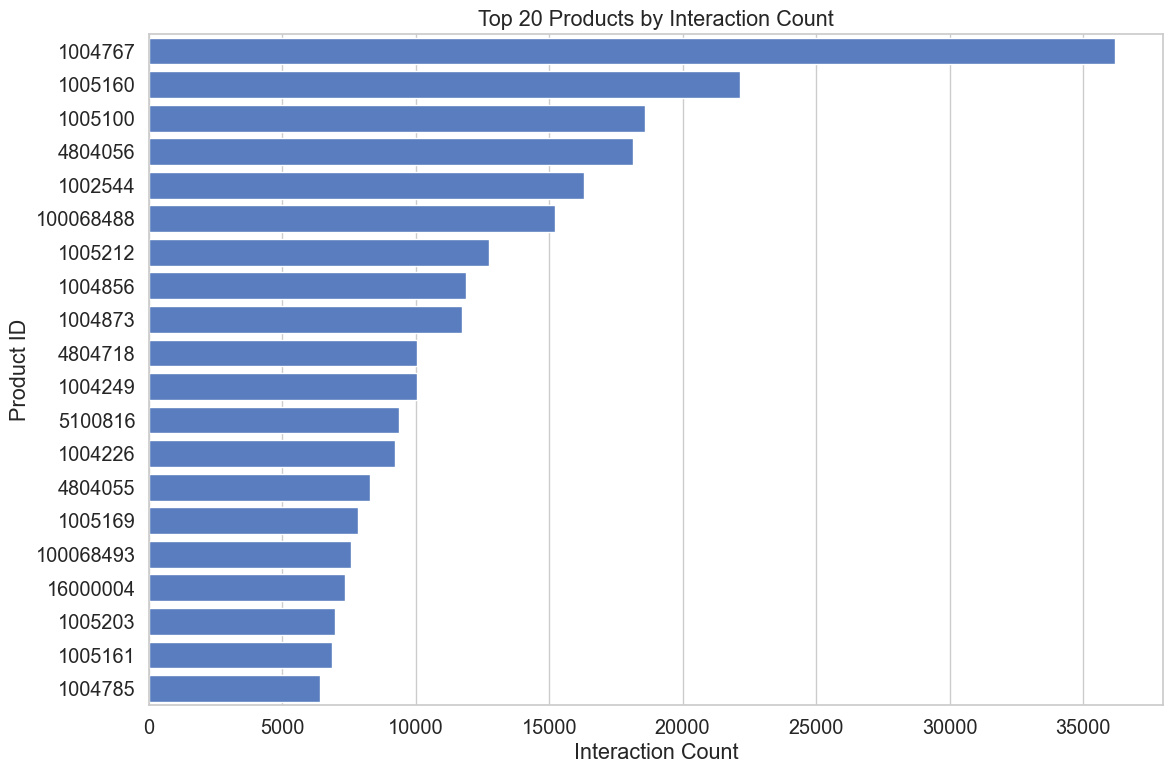

In [7]:
plt.figure(figsize=(12, 8))
sns.barplot(x=top_products.values, y=top_products.index.astype(str))
plt.title("Top 20 Products by Interaction Count")   
plt.xlabel("Interaction Count")
plt.ylabel("Product ID")
plt.tight_layout()
plt.show()

### Acive Users
This section analyze which users are most active and how session activity is distributed across users.

In [8]:
user_counts = df["user_id"].value_counts().nlargest(15)
session_length = df.groupby("user_session").size().sort_values(ascending=False).head(15)

print("\nTop 15 users by number of interactions:\n", user_counts)
print("\nTop 15 users by session length:\n", session_length)


Top 15 users by number of interactions:
 user_id
597644399    2648
569335945     744
597400318     585
587686837     544
571320128     502
594413602     501
569938094     498
568804062     459
568819127     454
550985043     436
512475445     435
593731440     414
594718064     412
594137269     374
615702426     361
Name: count, dtype: int64

Top 15 users by session length:
 user_session
f3878721-f96f-472b-9ad3-42e7a62861d3    116
c3e41eab-c552-4ca7-8261-ef2f85ec2aa9    111
771de524-4f0d-47c3-b4f5-317931589610    110
8b440989-39c2-4bd8-8164-cc95a152ff58    105
b8cff14d-d5ea-4f6f-8111-8c4f4053fa63    102
443babd7-477f-4d81-bd18-b1a7a29413e6     97
19faaa53-f1ea-f4ae-a825-1dad9f35c82e     95
831b1426-68e3-4e83-ac2a-1347086dfb0f     71
828b0681-50fe-47bd-8aa7-e9ff734ff9cd     69
bbcfedc9-3965-41af-bbb6-a75a3ae5c655     61
9eb512e3-7660-43a1-b1ff-d315035ac242     55
1bf74f86-3c3b-4b57-aa9e-822d12530ebc     39
14e27f0b-5851-45fa-9293-4ae7f20485ba     38
e38c2ed0-06f5-4a9e-bfa1-b25811047d3

C:\Users\phema\AppData\Local\Temp\ipykernel_7036\1941019664.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=user_counts.values, y=user_counts.index.astype(str), ax=axes[0], palette="rocket")
C:\Users\phema\AppData\Local\Temp\ipykernel_7036\1941019664.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=session_length.values, y=session_length.index.astype(str), ax=axes[1], palette="mako")


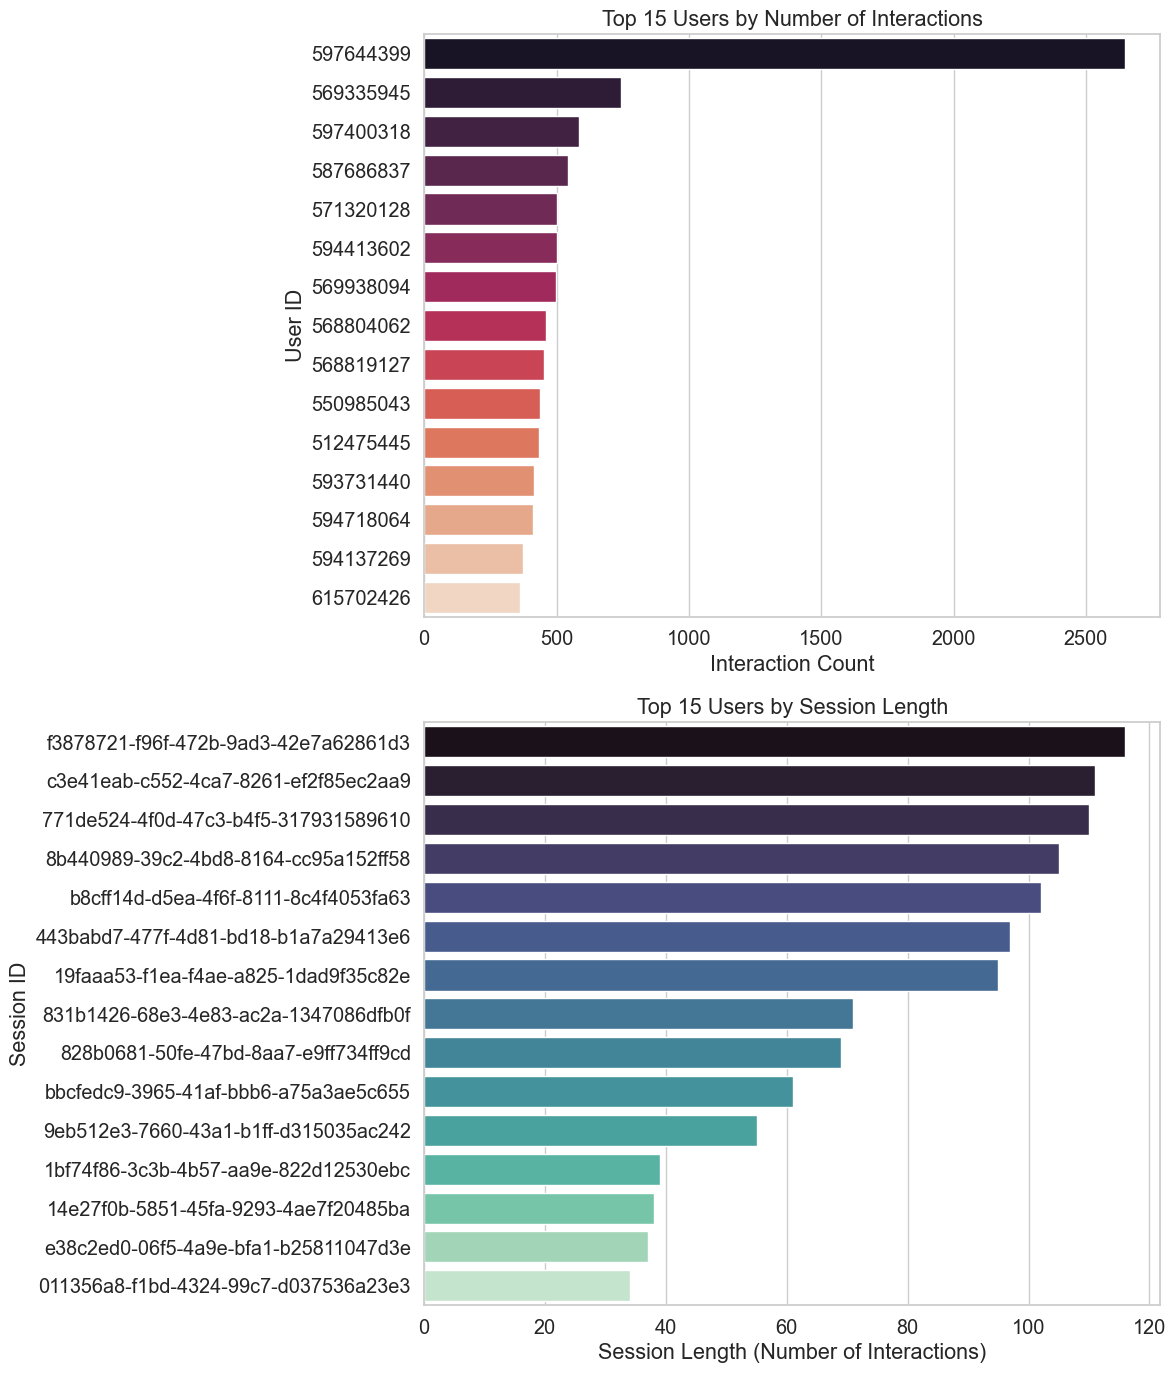

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

sns.barplot(x=user_counts.values, y=user_counts.index.astype(str), ax=axes[0], palette="rocket")
axes[0].set_title("Top 15 Users by Number of Interactions")
axes[0].set_xlabel("Interaction Count")
axes[0].set_ylabel("User ID")

sns.barplot(x=session_length.values, y=session_length.index.astype(str), ax=axes[1], palette="mako")
axes[1].set_title("Top 15 Users by Session Length")
axes[1].set_xlabel("Session Length (Number of Interactions)")
axes[1].set_ylabel("Session ID")

plt.tight_layout()
plt.show()

##### User Engagement Metrics

Average interactions per user: 2.19


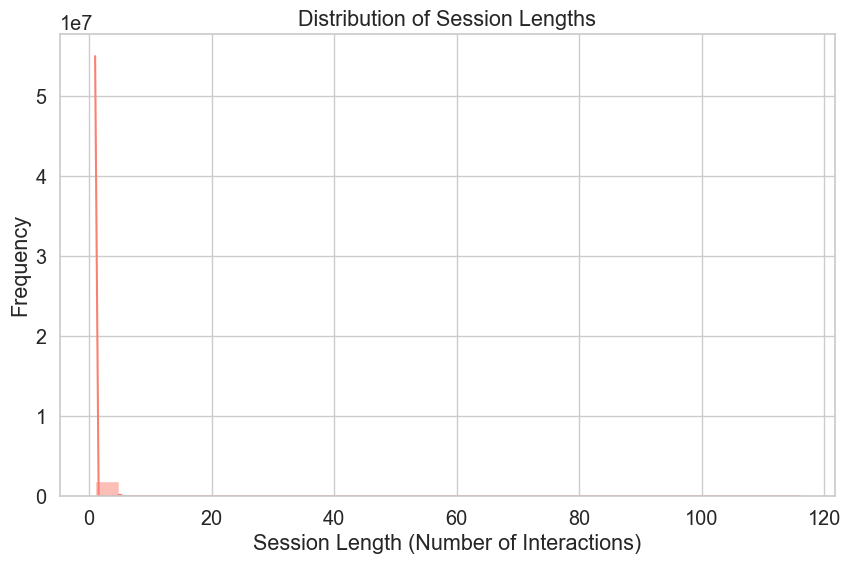

In [10]:
avg_interactions_per_user = df.groupby('user_id').size().mean()
print(f"Average interactions per user: {avg_interactions_per_user:.2f}")

session_lengths = df.groupby('user_session').size()
plt.figure(figsize=(10, 6))
sns.histplot(session_lengths, bins=30, kde=True, color='salmon')
plt.title('Distribution of Session Lengths')
plt.xlabel('Session Length (Number of Interactions)')
plt.ylabel('Frequency')
plt.show()

### Timeline Analysis
In this section we will look at hourly and weekday patterns to understand when activity is highest in the dataset.

In [11]:
weekday_mapping = {0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
time_by_hour = df["hour"].value_counts().sort_index()
df["day_of_week"] = df["day_of_week"].map(weekday_mapping)
grouped_day_names = (
    df["day_of_week"].value_counts().reindex(['Mon', 'Tues', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']).fillna(0)
)

C:\Users\phema\AppData\Local\Temp\ipykernel_7036\3452156901.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grouped_day_names.index, y=grouped_day_names.values, ax=axes[1], palette="viridis")


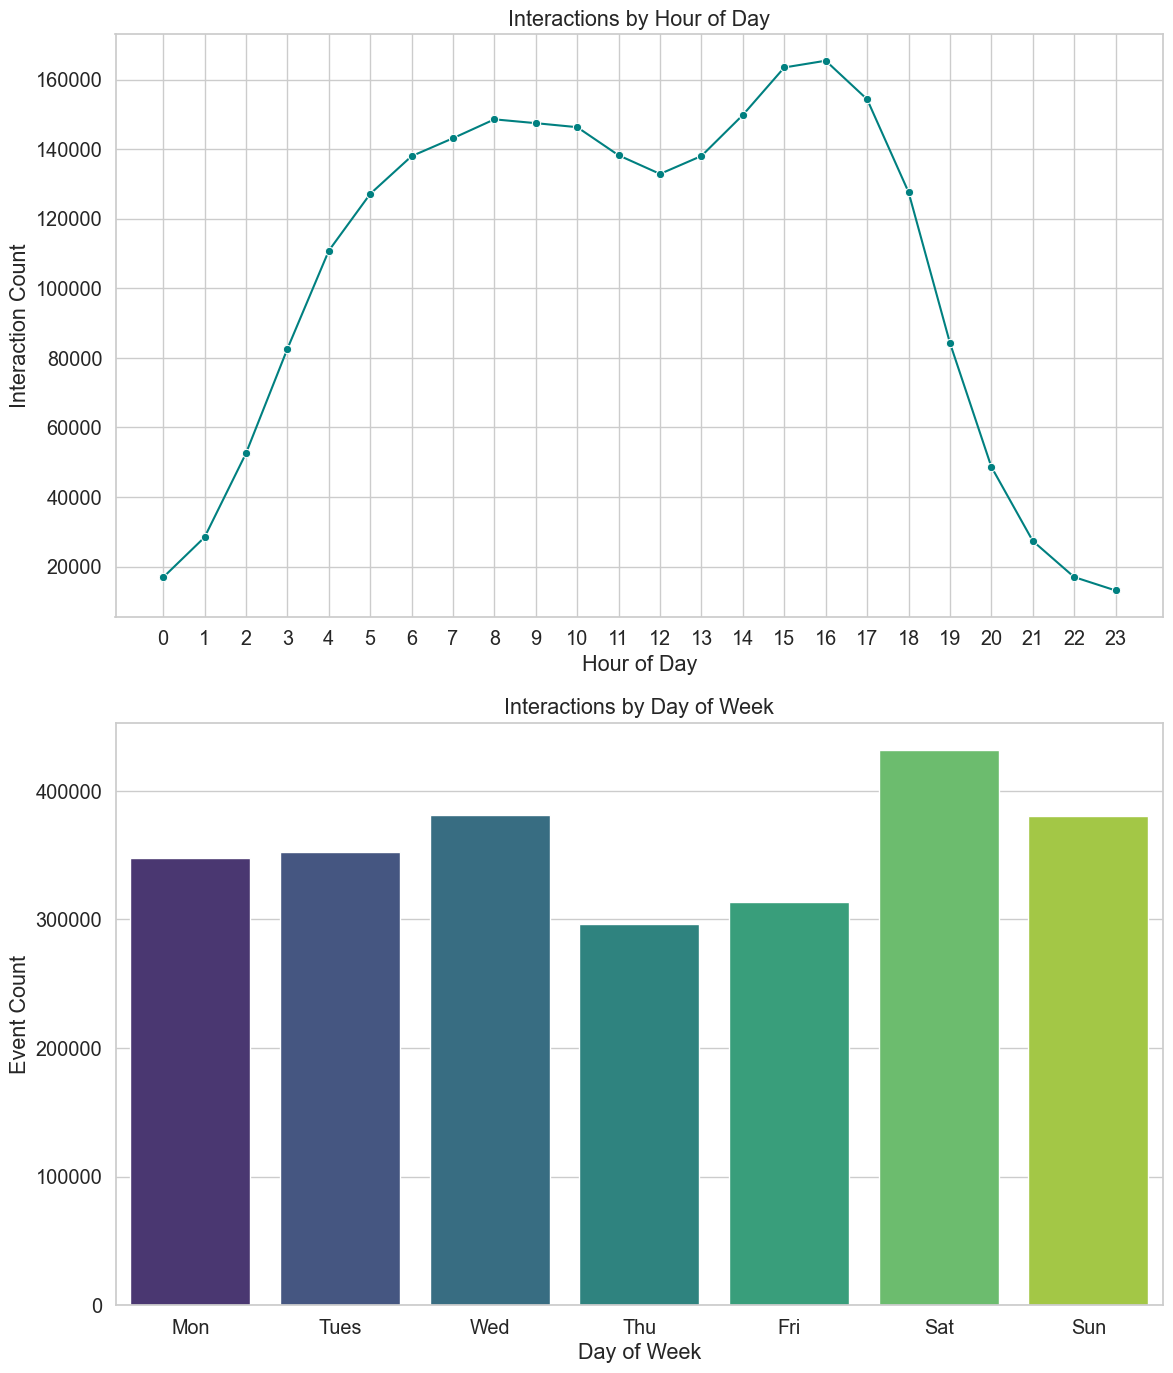

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

sns.lineplot(x=time_by_hour.index, y=time_by_hour.values, marker="o",ax=axes[0], color="teal")
axes[0].set_title("Interactions by Hour of Day")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Interaction Count")
axes[0].set_xticks(range(0, 24))

sns.barplot(x=grouped_day_names.index, y=grouped_day_names.values, ax=axes[1], palette="viridis")
axes[1].set_title("Interactions by Day of Week")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Event Count")

plt.tight_layout()
plt.show()

##### Product Category Popularity Over Time

C:\Users\phema\AppData\Local\Temp\ipykernel_7036\3812238969.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top_categories, x='category_id', palette='tab10')
C:\Users\phema\AppData\Local\Temp\ipykernel_7036\3812238969.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Category ID')


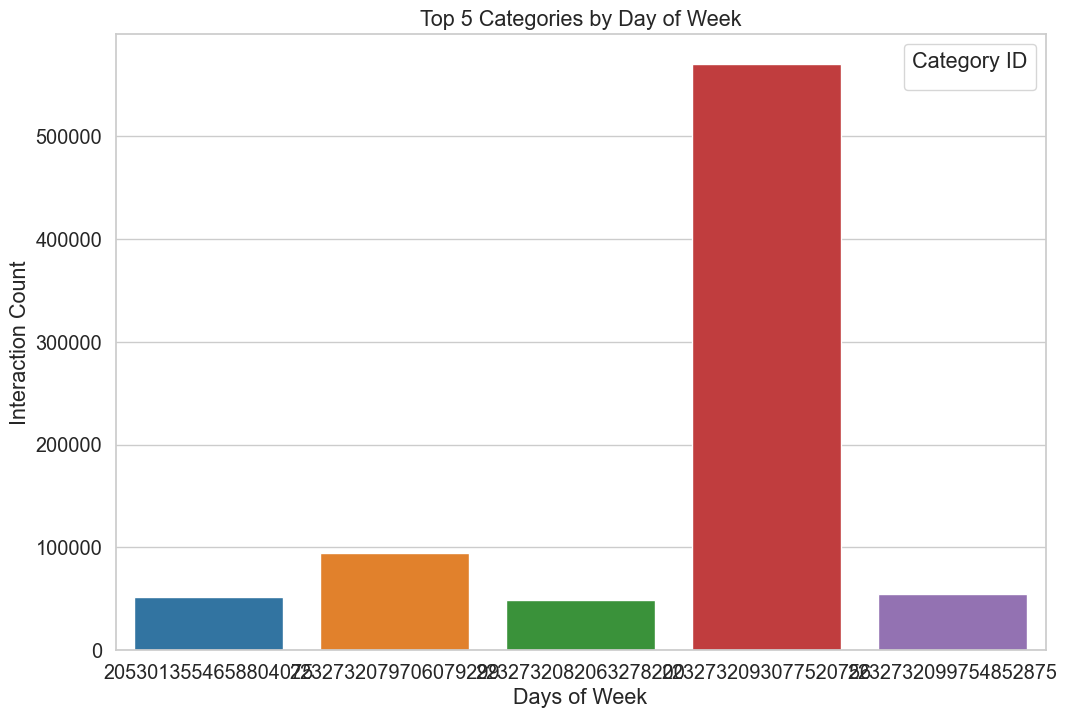

In [13]:
top_categories = df['category_id'].value_counts().index[:5]
df_top_categories = df[df['category_id'].isin(top_categories)]

plt.figure(figsize=(12, 8))
sns.countplot(data=df_top_categories, x='category_id', palette='tab10')
plt.title("Top 5 Categories by Day of Week")
plt.xlabel("Days of Week")
plt.ylabel("Interaction Count")
plt.legend(title='Category ID')
plt.show()

##### Activity Heatmap by Hour of Day

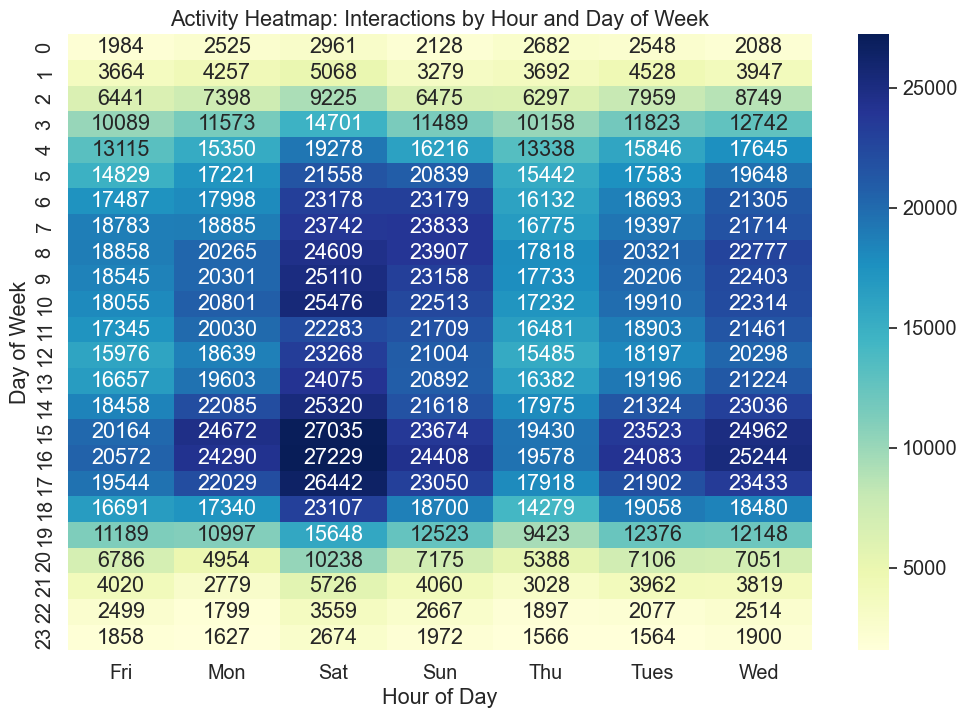

In [14]:
activity_pivot = df.pivot_table(index='hour', columns='day_of_week', values='price', aggfunc='count').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(activity_pivot, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title("Activity Heatmap: Interactions by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

### EDA ready Dataset
Final step is to save the cleaned dataset with derived features so it is ready for modeling and further analysis.

##### Correlation Analysis

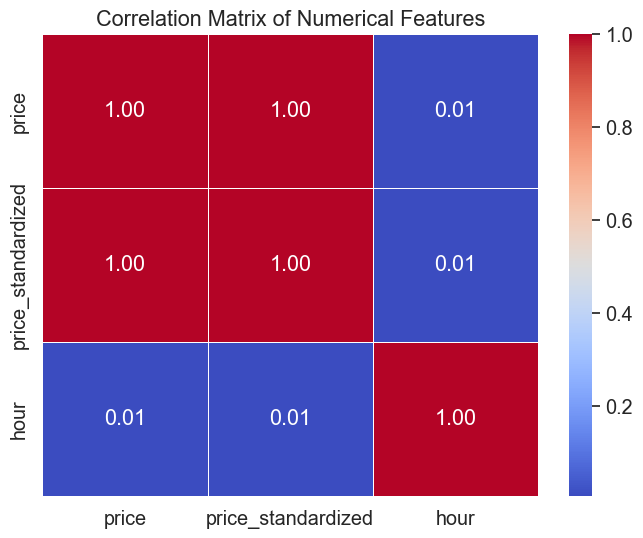

In [15]:
numerical_cols = ['price', 'price_standardized', 'hour']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [16]:
eda_df = df.copy()

eda_df["product_interaction_count"] = eda_df.groupby("product_id")["product_id"].transform("count")
eda_df["user_interaction_count"] = eda_df.groupby("user_id")["user_id"].transform("count")
eda_df["session_interaction_count"] = eda_df.groupby("user_session")["user_session"].transform("count")

In [17]:
eda_df.to_csv("2020-Feb-EDA-Features.csv", index=False)
print("EDA features added and saved to 2020-Feb-EDA-Features.csv")

EDA features added and saved to 2020-Feb-EDA-Features.csv


In [18]:
eda_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2502121 entries, 0 to 2502120
Data columns (total 12 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   product_id                 int64  
 1   category_id                int64  
 2   price                      float64
 3   user_id                    int64  
 4   price_standardized         float64
 5   hour                       int64  
 6   day_of_week                str    
 7   user_session               str    
 8   price_binned               str    
 9   product_interaction_count  int64  
 10  user_interaction_count     int64  
 11  session_interaction_count  int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 229.1 MB


In [19]:
eda_df.describe()

,product_id,category_id,price,user_id,price_standardized,hour,product_interaction_count,user_interaction_count,session_interaction_count
count,2.502121e+06,2.502121e+06,2.502121e+06,2.502121e+06,2.502121e+06,2.502121e+06,2.502121e+06,2.502121e+06,2.502121e+06
mean,2.803566e+07,2.187277e+18,1.941741e+02,5.633038e+08,-2.616945e-01,1.123941e+01,2.228360e+03,1.055864e+01,1.768096e+00
std,3.671778e+07,7.807656e+16,1.788196e+02,3.823454e+07,4.987282e-01,5.241157e+00,5.727925e+03,9.083528e+01,2.368413e+00
min,1.000978e+06,2.053014e+18,0.000000e+00,2.216536e+07,-8.032466e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,2.501352e+06,2.055157e+18,5.406000e+01,5.235438e+08,-6.524732e-01,7.000000e+00,2.700000e+01,1.000000e+00,1.000000e+00
50%,1.120010e+07,2.232732e+18,1.425800e+02,5.637543e+08,-4.055907e-01,1.100000e+01,1.470000e+02,3.000000e+00,1.000000e+00
75%,2.871926e+07,2.232732e+18,2.790400e+02,6.006906e+08,-2.500350e-02,1.600000e+01,1.086000e+03,6.000000e+00,2.000000e+00
max,1.001447e+08,2.250811e+18,7.823900e+02,6.220899e+08,1.378841e+00,2.300000e+01,3.618600e+04,2.648000e+03,1.160000e+02
